# Jacobian Lens (jspace) - walkthrough

A hands-on notebook for the **Jacobian lens** from Anthropic's paper
[*Verbalizable Representations Form a Global Workspace in Language Models*](https://transformer-circuits.pub/2026/workspace/index.html).

**Reference implementation:** [github.com/anthropics/jacobian-lens](https://github.com/anthropics/jacobian-lens).

Sections:

1. **What is jspace?** - the math, from scratch
2. **Setup** - install `jlens`, load a HuggingFace model, load a pre-fitted lens
3. **How to use jlens** - the whole public API in one place
4. **Basic readout** - J-lens vs logit lens across all layers, with plot
5. **jspace across task types** - factual, arithmetic, code, two-hop
6. **Interventions** - sparse readout, steering, ablation, patching (with plots)
7. **Replicate paper experiments** - two-hop reasoning + concept swap
8. **Fit your own lens** - on any HuggingFace decoder model

---

## 1. What is jspace?

Let's build the definition from scratch.  This is the longest section - once you understand this,
the rest of the notebook is mostly plumbing.

### 1.1  The transformer residual stream

A decoder transformer maintains, at every token position $t$ and every layer $\ell$, a vector
$h_{\ell, t} \in \mathbb{R}^{d_{\text{model}}}$ called the **residual stream**.
Layers read from it and write to it additively:

$$
h_{\ell+1, t} \;=\; h_{\ell, t} \;+\; f_{\ell}(h_{\ell, \bullet})
$$

The final layer $L$'s residual stream $h_{L, t}$ is projected to logits by the unembedding matrix $W_U$:

$$
\text{logits}_t \;=\; W_U \, h_{L, t}
$$

### 1.2  The logit lens (warm-up)

The **logit lens** applies $W_U$ to $h_{\ell, t}$ *at an intermediate layer* $\ell < L$, pretending
that layer's activation IS the final layer:

$$
\text{logit-lens}(h_{\ell, t}) \;=\; \mathrm{softmax}(W_U \, h_{\ell, t})
$$

This works OK in late layers.  It's noisy and unreadable in **early and middle layers**, because
those activations still need many more layers to reach the final residual - $W_U$ applied directly
doesn't respect that.

### 1.3  The Jacobian lens - the key idea

Instead of pretending $h_{\ell, t}$ IS the final layer, ask: **which direction in the final layer
does a small change at layer $\ell$ propagate to?**

That's a Jacobian.  For a source position $t$ and any downstream position $t' \geq t$:

$$
\frac{\partial h_{L, t'}}{\partial h_{\ell, t}} \;\in\; \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}
$$

The **J-lens matrix** is the *average* of this Jacobian, taken over:

- the source position $t$
- all subsequent positions $t' \geq t$
- a corpus of $\sim 1000$ generic pretraining-like prompts

$$
J_{\ell} \;=\; \mathbb{E}_{t,\; t' \geq t,\; \text{prompt}} \left[ \frac{\partial h_{L, t'}}{\partial h_{\ell, t}} \right]
$$

One $d_{\text{model}} \times d_{\text{model}}$ matrix per layer.  The **J-lens** is:

$$
\text{J-lens}(h_{\ell, t}) \;=\; \mathrm{softmax}\big( W_U \, \mathrm{norm}(J_{\ell} \, h_{\ell, t}) \big)
$$

### 1.4  J-lens vectors: one direction per vocabulary token

Let $u_v \in \mathbb{R}^{d_{\text{model}}}$ be the $v$-th row of $W_U$ (the unembedding for vocab token $v$).
The lens score for token $v$ is the $v$-th entry of $W_U J_\ell h$.  Rearranging:

$$
(W_U \, J_{\ell} \, h)_v \;=\; u_v^\top \, J_{\ell} \, h \;=\; (J_{\ell}^\top u_v)^\top \, h
$$

So we pre-compute one vector per vocab token and reduce the lens score to a single dot product:

$$
v_{\ell, v} \;:=\; J_{\ell}^\top \, u_v \;\in\; \mathbb{R}^{d_{\text{model}}} \qquad\text{so that}\qquad (W_U \, J_{\ell} \, h)_v \;=\; v_{\ell, v}^\top \, h
$$

These are the **J-lens vectors**.  We compute them explicitly in §6 and use them for steering /
ablation / patching:

- **read**:  $s_v = v_{\ell, v}^\top h$ (how present is concept $v$)
- **add**:  $h \mathrel{+}= \alpha \, v_{\ell, v}$ (steering)
- **project out**:  $h \mathrel{-}= (v^\top h) / \|v\|^2 \cdot v$ (ablation)

### 1.5  The jspace

The **jspace** is the subspace of residual-stream space spanned by *actively used* J-lens vectors.

At any given activation $h_{\ell, t}$, only a handful of J-lens vectors are 'lit up' - the paper
empirically observes **no more than $\sim 25$** at a time.  So we can decompose:

$$
h_{\ell, t} \;=\; \underbrace{\sum_{i=1}^{k} c_i \, v_i}_{\text{jspace component}} \;+\; \underbrace{r}_{\text{non-jspace residual}}
$$

The jspace component is *usually a small fraction of the total activation variance* (**less than 10%**
in the paper's measurements), but it captures the **verbalizable content** - what the model is
'thinking about' in a form that could be reported.

### 1.6  Interventions - the point of all this

Because J-lens vectors are actual directions in residual-stream space, we can do surgery on them:

| Op | Formula | What it does |
|----|---------|--------------|
| Read a token's score | $s_v = v_{\ell, v}^\top h$ | how much is concept $v$ present |
| Steer (add) | $h' = h + \alpha \, v_{\ell, v}$ | inject concept $v$ |
| Ablate | $h' = h - (v^\top h) / \|v\|^2 \cdot v$ | remove concept $v$ |
| Patch (concept swap) | $h' = h + V (\sigma(c) - c)$ | swap concept $s \leftrightarrow t$, keep rest |

In the patch, $V = [v_s \; v_t]$, $c = V^\dagger h$, and $\sigma$ swaps coordinates.
This leaves everything orthogonal to $V$ unchanged.

### 1.7  Why this matters

The paper claims jspace is *the LLM's version of a global workspace*: a small set of representations
the rest of the model treats as **broadcast** (available to all downstream computation).  Evidence:

- **Verbalizable**: reading the top-k J-lens tokens gives interpretable words.
- **Flexibly reused**: swap Italy -> France at layer $\ell$, and downstream circuits for
  *capital, language, currency* all read the new concept.
- **Small**: less than 10% of activation variance.
- **Selective**: ablating the jspace destroys multi-hop reasoning but not automatic completions.

OK - now let's actually run the thing.

---

## 2. Setup

We install `jlens`, load a HuggingFace model, and pull a pre-fitted lens from the Hub.
The paper's released lenses are for **Qwen 3.5 4B** and **Qwen 3.6 27B**.

In [1]:
!pip install git+https://github.com/anthropics/jacobian-lens.git

  Cloning https://github.com/anthropics/jacobian-lens.git to /tmp/pip-req-build-sqps20qx
  Running command git clone --filter=blob:none --quiet https://github.com/anthropics/jacobian-lens.git /tmp/pip-req-build-sqps20qx
  Resolved https://github.com/anthropics/jacobian-lens.git to commit 581d398613e5602a5af361e1c34d3a92ea82ba8e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for jlens: filename=jlens-0.1.0-py3-none-any.whl size=49952 sha256=65da5b8341b5d3727699c1642040ad0703404a4786ec3394c18ab2fd44b7e1bb
  Stored in directory: /tmp/pip-ephem-wheel-cache-2gv3lcun/wheels/44/7f/71/b488a70d41bd2cf5c3fa3653df390f839d2472ae0e7586e526
Successfully built jlens


In [2]:
# ---- Install (uncomment on first run) ----
# !pip install torch transformers accelerate huggingface_hub matplotlib
# !pip install git+https://github.com/anthropics/jacobian-lens.git

# ---- Standard imports ----
import torch
import numpy as np
import matplotlib.pyplot as plt
import transformers
import jlens

jlens.configure_logging()

print('torch:', torch.__version__)
print('cuda:', torch.cuda.is_available(), '  mps:', torch.backends.mps.is_available())
print('jlens exports:', [x for x in dir(jlens) if not x.startswith('_')])

torch: 2.11.0+cu128
cuda: True   mps: False
jlens exports: ['ActivationRecorder', 'HFLensModel', 'JacobianLens', 'Layout', 'LensModel', 'configure_logging', 'fit', 'fitting', 'from_hf', 'hf', 'hooks', 'jacobian_for_prompt', 'lens', 'protocol']


In [3]:
# ---- Model + lens config ----
# Both Qwen 3.5 4B and 3.6 27B have pre-fitted lenses on the Hub.  4B is laptop-friendly.
MODEL_NAME     = 'Qwen/Qwen3.5-4B'
LENS_REPO      = 'neuronpedia/jacobian-lens'
LENS_REVISION  = 'qwen-n1000'
LENS_FILE      = 'qwen3.5-4b/jlens/Salesforce-wikitext/Qwen3.5-4B_jacobian_lens_n1000.pt'

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
DTYPE  = torch.bfloat16 if DEVICE != 'cpu' else torch.float32
print(f'device: {DEVICE}   dtype: {DTYPE}')

device: cuda   dtype: torch.bfloat16


In [4]:
# ---- Load base model + wrap for jlens ----
# `jlens.from_hf` wraps a HuggingFace AutoModelForCausalLM into an HFLensModel that exposes
# n_layers, d_model, and a compatible forward pass for lens.apply().
hf_model  = transformers.AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=DTYPE).to(DEVICE)
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME)

model = jlens.from_hf(hf_model, tokenizer)
print(f'n_layers = {model.n_layers}   d_model = {model.d_model}   vocab = {tokenizer.vocab_size}')

config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

n_layers = 32   d_model = 2560   vocab = 248044


In [5]:
# ---- Load pre-fitted Jacobian lens ----
# The .pt file is one (d_model, d_model) Jacobian matrix per source layer.
lens = jlens.JacobianLens.from_pretrained(LENS_REPO, filename=LENS_FILE, revision=LENS_REVISION)

print(lens)
print(f'lens has {len(lens.source_layers)} layer matrices')
print(f'source layers: {lens.source_layers[:5]} ... {lens.source_layers[-5:]}')

# lens.jacobians is a dict {layer_index -> (d_model, d_model) tensor}
J_example = lens.jacobians[lens.source_layers[len(lens.source_layers) // 2]]
print(f'each J is a {tuple(J_example.shape)} tensor of dtype {J_example.dtype}')

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

JacobianLens(d_model=2560, n_prompts=1000, source_layers=[0..30] (31 layers))
lens has 31 layer matrices
source layers: [0, 1, 2, 3, 4] ... [26, 27, 28, 29, 30]
each J is a (2560, 2560) tensor of dtype torch.float32


**Not exposed by jlens** (we implement by hand): sparse decomposition, steering, ablation, patching hooks.

---

## 3. How to use `jlens`

Before we start doing experiments, here's the whole public API of the library in one place.
This is the minimum surface area you need to know.

### 3.1  What `jlens` exports

```python
jlens.from_hf              # wrap a HuggingFace model  ->  HFLensModel
jlens.HFLensModel          # class - what from_hf returns
jlens.LensModel            # protocol - the interface HFLensModel implements
jlens.Layout               # layout info about the wrapped model

jlens.JacobianLens         # the fitted lens (one J_l matrix per layer)
jlens.fit                  # fit a lens on a corpus of prompts
jlens.jacobian_for_prompt  # single-prompt Jacobian (used inside fit)

jlens.ActivationRecorder   # context manager for capturing residuals
jlens.configure_logging    # log setup
```

That's the entire top-level namespace.  If you need something else (steering hooks, sparse coding,
etc.) you write it yourself using PyTorch - which is what we do in §6.

### 3.2  `HFLensModel` (wraps your HuggingFace model)

```python
model = jlens.from_hf(hf_model, tokenizer)
```

**Attributes:**

- `model.n_layers`  - number of transformer blocks
- `model.d_model`   - hidden dim of the residual stream
- Everything else on `hf_model` still works (`hf_model.model.layers[L]`, `.generate()`, `.forward()`, etc.)

`from_hf` also handles the layout differences between Qwen / Llama / Mistral automatically.

### 3.3  `JacobianLens` (the fitted lens object)

**Loading a pre-fitted lens from the HuggingFace Hub:**

```python
lens = jlens.JacobianLens.from_pretrained(
    'neuronpedia/jacobian-lens',
    filename='qwen3.5-4b/jlens/Salesforce-wikitext/Qwen3.5-4B_jacobian_lens_n1000.pt',
    revision='qwen-n1000',
)
```

**Attributes:**

- `lens.jacobians`        - `dict[int, Tensor[d_model, d_model]]` - the raw J_l matrices
- `lens.source_layers`    - `list[int]` - sorted list of fitted layer indices
- `lens.n_prompts`        - `int` - number of prompts used during fit
- `lens.d_model`          - `int` - residual stream width

**Saving:**

```python
lens.save('my_lens.pt')
```

### 3.4  The main call: `lens.apply(...)`

This is where you'll spend most of your time.  It runs one forward pass with hooks, transports
each requested layer's residual through `J_l`, and unembeds to give per-token lens scores.

```python
lens_logits, model_logits, input_ids = lens.apply(
    model,               # HFLensModel from jlens.from_hf
    prompt,               # str
    layers=[8, 16, 24],   # which layers to read at (must be in lens.source_layers)
    positions=[-1],       # which token positions (negatives count from end)
    use_jacobian=True,    # False -> vanilla logit lens (skip J transport)
)
```

**Returns a 3-tuple:**

- `lens_logits`  - `dict[int, Tensor[n_positions, vocab_size]]` - one entry per requested layer
- `model_logits` - `Tensor[n_positions, vocab_size]` - final-layer logits at those positions
- `input_ids`    - `Tensor[seq_len]` - the encoded prompt

**Reading a top-k list from the output:**

```python
layer_16_probs = lens_logits[16][0].softmax(-1)              # (vocab,)
top5           = layer_16_probs.topk(5).indices
top5_tokens    = [tokenizer.decode([t]) for t in top5]
```

### 3.5  Fitting your own lens: `jlens.fit(...)`

```python
prompts = ['Some text ...', 'More text ...', ...]   # any iterable of strings

new_lens = jlens.fit(
    model,                      # HFLensModel
    prompts=prompts,
    dim_batch=32,               # memory knob (smaller = less mem, more passes)
    max_seq_len=128,
    checkpoint_path='ckpt.pt',  # optional - saves after every prompt
)
new_lens.save('my_lens.pt')
```

100 prompts is enough for a usable lens.  Released lenses use ~1000.

**How it works internally:** for each prompt, `jacobian_for_prompt` computes
$\partial h_L / \partial h_\ell$ for every fitted layer $\ell$ via a series of backward passes
on a retained graph.  These are averaged across all prompts to produce the $J_\ell$ matrices.
The `dim_batch` parameter is how many components of `h_L` are backpropped at once - smaller batches
trade memory for wall-clock time.

### 3.6  Capturing raw residual streams: `ActivationRecorder`

`lens.apply` gives you *lens outputs*.  If you want the raw residual $h_{\ell, t}$ itself
(to do custom interventions, to project onto vectors, etc.), use `ActivationRecorder`:

```python
blocks = list(hf_model.model.layers)          # ALL transformer blocks as a list
input_ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device)

with jlens.ActivationRecorder(blocks, at=[8, 16, 24]) as rec:
    with torch.no_grad():
        hf_model(input_ids=input_ids)

# rec.activations is a dict {layer_idx -> Tensor[batch, seq_len, d_model]}
h_at_layer_16 = rec.activations[16]           # (1, seq_len, d_model)
h_at_pos_last = h_at_layer_16[0, -1]           # (d_model,)
```

**Signature:**  `ActivationRecorder(blocks: Sequence[nn.Module], at: Iterable[int])`.
The `at=[...]` indices refer to positions in the `blocks` list - typically these match the
layer indices you'd use with `lens.jacobians[L]`.

### 3.7  Computing a J-lens vector for a single token

The library gives you the raw $J_\ell$ matrix and the model gives you the unembedding $W_U$.
The J-lens vector for token $v$ at layer $\ell$ is:

$$v_{\ell, v} \;=\; J_{\ell}^\top \, u_v$$

```python
def jlens_vector(lens, L, token_id, hf_model):
    J   = lens.jacobians[L]                              # (d_model, d_model)
    W_U = hf_model.get_output_embeddings().weight        # (vocab, d_model)
    u_v = W_U[token_id].detach()                          # (d_model,)
    return J.to(u_v.device, dtype=u_v.dtype).T @ u_v     # (d_model,)
```

This helper is exactly what we use in §6 for steering / ablation / patching.  It's not in `jlens`
itself - you write it once, ~5 lines, and never think about it again.

### 3.8  Interventions - use PyTorch forward hooks

`jlens` doesn't ship intervention helpers.  Just use `torch.nn.Module.register_forward_hook`
on the transformer blocks.  Steering example:

```python
def steer_hook(v, alpha):
    def hook(module, inp, out):
        # HF blocks return either a Tensor or a (Tensor, ...) tuple
        h = out[0] if isinstance(out, tuple) else out
        h = h + alpha * v.to(h.device, dtype=h.dtype)
        return (h,) + out[1:] if isinstance(out, tuple) else h
    return hook

handle = hf_model.model.layers[L].register_forward_hook(steer_hook(v, 3.0))
try:
    output = hf_model.generate(...)
finally:
    handle.remove()
```

In this notebook we wrap that in three `@contextmanager` helpers - `steer()`, `ablate()`,
`patch_swap()` - defined in §6.  Same pattern, cleaner call site:

```python
with steer(hf_model, layer=L, vector=v, alpha=3.0):
    output = generate(hf_model, tokenizer, prompt)
```

### 3.9  The whole workflow at a glance

```
hf_model, tokenizer = load HuggingFace model
        |
        v  jlens.from_hf
        model  (HFLensModel)
        |
        +---- jlens.fit(model, prompts)  -->  lens  (or JacobianLens.from_pretrained)
        |                                     |
        v                                     v
        +---> lens.apply(model, prompt) ---> (lens_logits, model_logits, input_ids)
        |                                     |
        v                                     v  softmax + topk = readout
        ActivationRecorder(blocks, at=[L])
               |
               v
               raw h at (L, t)  ---(v = J.T @ u_v)--->  do interventions with forward hooks
```

Everything below uses only these calls.  Now let's actually run some.

---

## 4. Basic readout: J-lens vs logit lens

Pick a factual prompt and read out top-5 tokens at each layer for both lenses.

Note: `lens.apply()` returns 3 items:

- `lens_logits_dict`: `{layer_idx: [n_positions, vocab_size]}`
- `model_logits`: final-layer logits, `[n_positions, vocab_size]`
- `input_ids`: the encoded prompt

In [6]:
# ---- Two-hop factual prompt: model must first think 'Italy', then answer 'Euro' ----
prompt = 'Fact: The currency used in the country shaped like a boot is'

# Probe 4 depths that fall inside the LENS's source_layers (not all layers may be fit).
sl = lens.source_layers
layers_to_probe = [sl[len(sl) // 4], sl[len(sl) // 2], sl[len(sl) // 4 * 3], sl[-1]]
print(f'probing layers: {layers_to_probe}   (out of source_layers = {sl[0]}..{sl[-1]})')

# ---- J-lens: transport with J_l first, then unembed ----
jlens_logits, model_logits, input_ids = lens.apply(model, prompt, layers=layers_to_probe, positions=[-2])

# ---- Logit lens: same call with use_jacobian=False ----
logit_lens_logits, _, _ = lens.apply(
    model, prompt, layers=layers_to_probe, positions=[-2], use_jacobian=False
)

def top5(logits):
    '''Top 5 tokens from a (vocab,) logits row, decoded as strings.'''
    return [tokenizer.decode([t]) for t in logits.topk(5).indices]

for L in layers_to_probe:
    print(f'L{L:>3}   logit-lens: {top5(logit_lens_logits[L][0])}')
    print(f'L{L:>3}   J-lens:     {top5(jlens_logits[L][0])}')
    print()
print(f'actual model output (final layer): {top5(model_logits[0])}')

probing layers: [7, 15, 21, 30]   (out of source_layers = 0..30)
L  7   logit-lens: ['UDI', 'GPC', 'ิร์', 'edom', ' heel']
L  7   J-lens:     [' `', ' *', ' boots', 'iness', 'ing']

L 15   logit-lens: ['วย', '举世', 'shaw', 'rea', ' Lager']
L 15   J-lens:     ['?', '？', '**?', "'?", '____']

L 21   logit-lens: ['soles', '袜', 'leneck', '😀', 'boot']
L 21   J-lens:     ['.\\"', '-shaped', '/boot', '.\\', ' Italy']

L 30   logit-lens: [' is', ' shape', '-shaped', ' heel', ' shaped']
L 30   J-lens:     [' is', ' shape', ' shaped', '-shaped', ' heel']

actual model output (final layer): [' is', ' in', ' on', '.', ' with']


You should see the J-lens surface interpretable content (e.g. `Italy`, `heel`, `boot`, ...)
at layers where the logit lens is still noise.

Now let's sweep **all** layers of the lens and plot the top-1 token probability across depth.

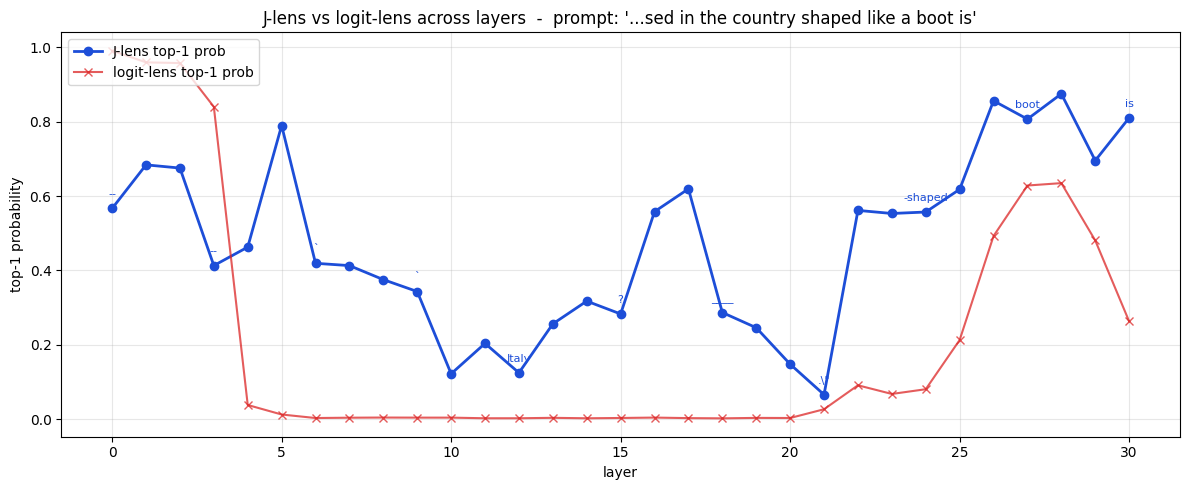

 layer          J-lens top   J-lens prob   logit-lens prob
     0                '--'         0.567             0.991
     1                '``'         0.684             0.959
     2                 '`'         0.675             0.957
     3                '--'         0.413             0.840
     4                 '`'         0.463             0.038
     5                 '`'         0.790             0.012
     6                 '`'         0.419             0.003
     7                 '`'         0.413             0.004
     8                 '`'         0.375             0.004
     9                 '`'         0.343             0.004
    10                 '`'         0.122             0.004
    11               '意大利'         0.204             0.002
    12             'Italy'         0.125             0.002
    13              '____'         0.256             0.003
    14                 '？'         0.317             0.002
    15                 '?'         0.283             0.0

In [7]:
# ---- Sweep every layer the lens was fitted on, at the last-content-token position ----
all_layers = list(lens.source_layers)

jl_all, _, _ = lens.apply(model, prompt, layers=all_layers, positions=[-2])
ll_all, _, _ = lens.apply(model, prompt, layers=all_layers, positions=[-2], use_jacobian=False)

# For each layer, get the top-1 token id and its probability under both lenses.
jl_probs = np.array([jl_all[L][0].softmax(-1).max().item() for L in all_layers])
ll_probs = np.array([ll_all[L][0].softmax(-1).max().item() for L in all_layers])
jl_tokens = [tokenizer.decode([jl_all[L][0].argmax().item()]).strip() for L in all_layers]

# ---- PLOT: top-1 probability vs layer, both lenses ----
fig, ax = plt.subplots(figsize=(12, 5))
xs = np.array(all_layers)
ax.plot(xs, jl_probs, 'o-', label='J-lens top-1 prob', color='#1d4ed8', linewidth=2)
ax.plot(xs, ll_probs, 'x-', label='logit-lens top-1 prob', color='#dc2626', linewidth=1.5, alpha=0.75)

# Annotate every 3rd layer with the J-lens top token.
for i in range(0, len(all_layers), 3):
    ax.annotate(jl_tokens[i], (xs[i], jl_probs[i]),
                xytext=(0, 8), textcoords='offset points',
                fontsize=8, ha='center', color='#1d4ed8')

ax.set_xlabel('layer')
ax.set_ylabel('top-1 probability')
ax.set_title(f"J-lens vs logit-lens across layers  -  prompt: '...{prompt[-40:]}'")
ax.grid(alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Print the full table
print(f'{"layer":>6}  {"J-lens top":>18}  {"J-lens prob":>12}  {"logit-lens prob":>16}')
for i, L in enumerate(all_layers):
    print(f'{L:>6}  {repr(jl_tokens[i]):>18}  {jl_probs[i]:>12.3f}  {ll_probs[i]:>16.3f}')

---

## 5. Show jspace across different task types

Does the J-lens surface interpretable concepts on *all* kinds of prompts?  We'll try five task
types and probe **every** fitted layer, then print the layer where the target concept is most
confident.

Probing every layer (not just one middle layer) is important - the paper's workspace range is
38-92% depth, which is a wide window, and the 'best' layer varies by task.

In [8]:
# ---- 6 prompts spanning different capabilities ----
# Base Qwen 3.5 4B (no instruction-tuning) does completion-style continuations.  Prompts that
# work best are ones with an obvious factual continuation.
TASK_PROMPTS = [
    ('factual-single',  'The capital of France is',                          'Paris'),
    ('factual-single',  'The largest planet in our solar system is',         'Jupiter'),
    ('two-hop',         'The currency used in the country shaped like a boot is', 'Italy'),
    ('two-hop',         'The capital of the country whose flag has a maple leaf is', 'Canada'),
    ('completion',      'Twinkle twinkle little',                            'star'),
    ('arithmetic',      'Two plus two equals',                               'four'),
]

all_layers = list(lens.source_layers)

def target_prob_by_layer(prompt_text, target_str):
    '''For every fitted layer, get P(target token) at position=-1 under the J-lens.'''
    tok_ids = tokenizer.encode(target_str, add_special_tokens=False)
    if not tok_ids:
        return None, None
    tok_id = tok_ids[0]
    jl, _, _ = lens.apply(model, prompt_text, layers=all_layers, positions=[-1])
    probs = np.array([jl[L][0].softmax(-1)[tok_id].item() for L in all_layers])
    return probs, tok_id

print(f'{"task":>16}  {"target":>12}  {"best layer":>12}  {"P(target)":>12}  top-3 tokens at best layer')
print('-' * 130)

for task, p, target in TASK_PROMPTS:
    probs, tok_id = target_prob_by_layer(p, target)
    if probs is None:
        continue
    best_i = int(np.argmax(probs))
    best_L = all_layers[best_i]
    # Top 3 tokens at that best layer
    jl, _, _ = lens.apply(model, p, layers=[best_L], positions=[-1])
    top3 = [tokenizer.decode([t]) for t in jl[best_L][0].topk(3).indices]
    print(f'{task:>16}  {target:>12}  L{best_L:>10}  {probs[best_i]:>12.3f}  {top3}')

            task        target    best layer     P(target)  top-3 tokens at best layer
----------------------------------------------------------------------------------------------------------------------------------
  factual-single         Paris  L        25         0.031  [' Paris', 'Paris', '巴黎']
  factual-single       Jupiter  L         2         0.000  [',', '.', ' a']
         two-hop         Italy  L        10         0.000  [' ...', '...', '？']
         two-hop        Canada  L        26         0.047  [' Canada', '____', 'Canada']
      completion          star  L        26         0.057  [' star', ' stars', ' Star']
      arithmetic          four  L        27         0.002  [' four', ' ____', ' what']


For each task the J-lens should locate the target concept at some layer - and the 'best' layer
will vary.  Two-hop prompts (boot/Italy, maple-leaf/Canada) have their intermediate concept
surface at middle-late layers, which is exactly the workspace range.

---

## 6. Interventions

Now we do surgery on the residual stream using J-lens vectors.  We need two things:

**1. The J-lens vector** for a token $v$ at layer $\ell$:

$$
v_{\ell, v} \;=\; J_{\ell}^\top \, u_v
$$

where $u_v$ is row $v$ of the unembedding.  Both are accessible: `lens.jacobians[L]` and
`hf_model.get_output_embeddings().weight`.

**2. A way to modify the residual stream during a forward pass.**  We use PyTorch's
`register_forward_hook` on the transformer block modules directly.

In [9]:
# ---- Helpers: J-lens vector + a way to find transformer blocks in the HF model ----
def jlens_vector(lens, L, token_id, hf_model):
    '''Return v_{L, token_id} = J[L].T @ u_v as a (d_model,) tensor on the model's device.'''
    J    = lens.jacobians[L]                                        # (d_model, d_model)
    W_U  = hf_model.get_output_embeddings().weight                  # (vocab, d_model)
    u_v  = W_U[token_id].detach()                                    # (d_model,)
    v    = J.to(u_v.device, dtype=u_v.dtype).T @ u_v                # (d_model,)
    return v

def transformer_blocks(hf_model):
    '''Return the sequence of transformer decoder blocks - what forward hooks attach to.'''
    # Qwen / Llama / Mistral all expose their block list at .model.layers
    return hf_model.model.layers

# Quick sanity check
L_test = lens.source_layers[len(lens.source_layers) // 2]
italy_id = tokenizer.encode('Italy', add_special_tokens=False)[0]
v = jlens_vector(lens, L_test, italy_id, hf_model)
print(f'v shape: {tuple(v.shape)}   norm: {v.norm().item():.4f}   dtype: {v.dtype}')

v shape: (2560,)   norm: 0.8633   dtype: torch.bfloat16


In [10]:
# ---- Generic hook builders for the 3 interventions ----
from contextlib import contextmanager

def _unwrap(output):
    '''HF transformer blocks return either a Tensor or (Tensor, ...) tuple.  Return (h, wrap).'''
    if isinstance(output, tuple):
        h, rest = output[0], output[1:]
        return h, (lambda new_h: (new_h,) + rest)
    return output, (lambda new_h: new_h)

@contextmanager
def steer(hf_model, layer, vector, alpha):
    '''Add alpha * vector to layer's residual output during forward pass.'''
    block = transformer_blocks(hf_model)[layer]
    v = vector
    def hook(mod, inp, out):
        h, wrap = _unwrap(out)
        h = h + alpha * v.to(h.device, dtype=h.dtype)
        return wrap(h)
    handle = block.register_forward_hook(hook)
    try:    yield
    finally: handle.remove()

@contextmanager
def ablate(hf_model, layer, vectors, strength=1.0):
    '''Project h onto span(vectors) and subtract  strength * projection.  strength=1 = full ablation.'''
    block = transformer_blocks(hf_model)[layer]
    V = torch.stack([v for v in vectors]).float()      # (k, d_model)
    def hook(mod, inp, out):
        h, wrap = _unwrap(out)
        Vd = V.to(h.device, dtype=h.dtype)
        # For each v: subtract strength * (v.h / |v|^2) * v
        proj = (h @ Vd.T) / (Vd.norm(dim=-1) ** 2 + 1e-8)   # (..., k)
        h = h - strength * (proj @ Vd)
        return wrap(h)
    handle = block.register_forward_hook(hook)
    try:    yield
    finally: handle.remove()

@contextmanager
def patch_swap(hf_model, layer, v_src, v_tgt):
    '''Swap coordinates of  V = [v_src, v_tgt]  in every activation at this layer.'''
    block = transformer_blocks(hf_model)[layer]
    V = torch.stack([v_src, v_tgt]).T.float()              # (d_model, 2)
    def hook(mod, inp, out):
        h, wrap = _unwrap(out)
        Vh = V.to(h.device, dtype=h.dtype)
        # Pseudoinverse:  c = pinv(V) @ h        (per-position)
        pinv = torch.linalg.pinv(Vh.float()).to(h.dtype)   # (2, d_model)
        c = h @ pinv.T                                       # (..., 2)
        # swap columns of c
        swapped = torch.stack([c[..., 1], c[..., 0]], dim=-1)
        h = h + (swapped - c) @ Vh.T
        return wrap(h)
    handle = block.register_forward_hook(hook)
    try:    yield
    finally: handle.remove()

print('helpers ready:  steer(), ablate(), patch_swap()')

helpers ready:  steer(), ablate(), patch_swap()


In [11]:
# ---- Small helper for next-token logits under a hook ----
@torch.no_grad()
def next_token_logits(hf_model, tokenizer, prompt_text, device=None):
    '''Return the logits over the vocabulary at position -1 for `prompt_text`.'''
    device = device or next(hf_model.parameters()).device
    input_ids = tokenizer(prompt_text, return_tensors='pt').input_ids.to(device)
    out = hf_model(input_ids=input_ids)
    return out.logits[0, -1].float()   # (vocab,)

@torch.no_grad()
def generate(hf_model, tokenizer, prompt_text, max_new_tokens=8, device=None):
    device = device or next(hf_model.parameters()).device
    input_ids = tokenizer(prompt_text, return_tensors='pt').input_ids.to(device)
    out = hf_model.generate(input_ids=input_ids, max_new_tokens=max_new_tokens,
                            do_sample=False, pad_token_id=tokenizer.eos_token_id)
    new_ids = out[0, input_ids.shape[1]:]
    return tokenizer.decode(new_ids, skip_special_tokens=True)

# Quick sanity: baseline continuation
base_out = generate(hf_model, tokenizer, prompt, max_new_tokens=8)
print(f'baseline continuation: {base_out!r}')

baseline continuation: ' the Euro.\nHypothesis:'


### 6a. Sparse readout: which J-lens vectors are active in $h_{\ell, t}$?

For each activation, we ask: **which top-K J-lens vectors have the largest dot product?**
That's the top-K entries of $W_U J_\ell h$, i.e. exactly what `lens.apply()` computes.
The tokens listed name the concepts the model has in mind.

(The paper uses non-negative gradient pursuit for a more careful sparse code, but the top-K
lens tokens are the same interpretation: 'these are the active concepts'.)

/tmp/ipykernel_1875/1645150928.py:25: UserWarning: Glyph 12290 (\N{IDEOGRAPHIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12290 (\N{IDEOGRAPHIC FULL STOP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


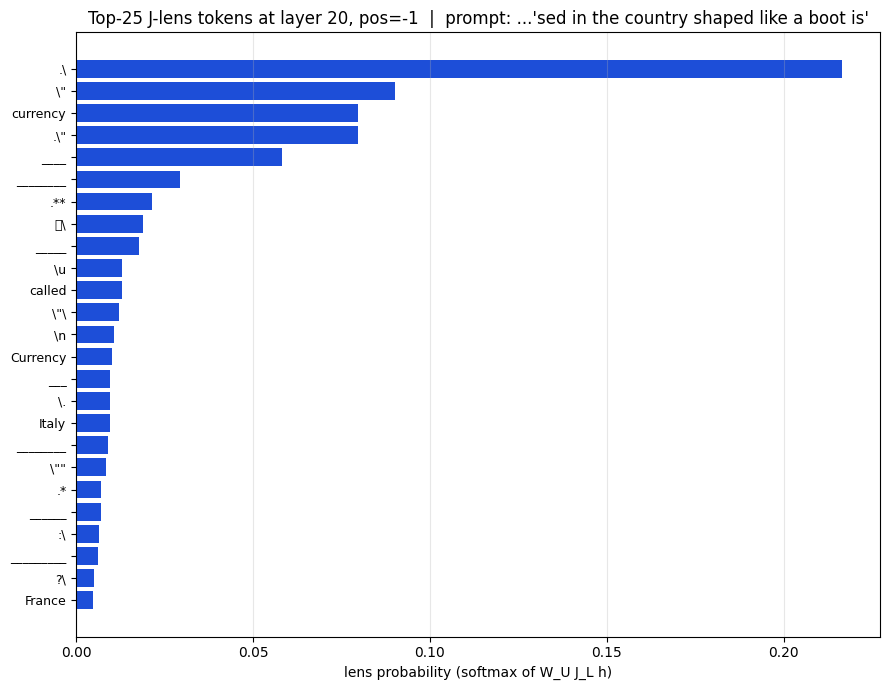

These are the concepts "active" in the residual stream at that layer.


In [12]:
# ---- Pick a target layer + prompt, get top-25 lens scores at position=-1 ----
# Use the best layer we found in §5 for the two-hop prompt.
TARGET_LAYER = 20    # somewhere in the workspace range (38-92% depth of 32-layer model)
K            = 25

jl_dict, _, _ = lens.apply(model, prompt, layers=[TARGET_LAYER], positions=[-1])
lens_logits = jl_dict[TARGET_LAYER][0]                     # (vocab,)
probs       = lens_logits.softmax(-1)                       # (vocab,) - normalized
top_probs, top_ids = probs.topk(K)                          # top-K by lens probability

# Decode
toks = [tokenizer.decode([i]).strip() or '<empty>' for i in top_ids.tolist()]
coeffs = top_probs.float().cpu().numpy()

# ---- PLOT: horizontal bar chart of top-K active tokens ----
fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(toks))
ax.barh(y, coeffs, color='#1d4ed8')
ax.set_yticks(y)
ax.set_yticklabels(toks, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('lens probability (softmax of W_U J_L h)')
ax.set_title(f'Top-{K} J-lens tokens at layer {TARGET_LAYER}, pos=-1  |  prompt: ...{prompt[-40:]!r}')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('These are the concepts "active" in the residual stream at that layer.')

**How much of the activation lives inside the jspace?**  We can quantify this: reconstruct $h$
as a non-negative linear combination of the top-K J-lens vectors, then compare the reconstruction
norm to the original.

In [13]:
# ---- Grab the raw activation h at (TARGET_LAYER, pos=-1) using ActivationRecorder ----
blocks = list(transformer_blocks(hf_model))
input_ids = tokenizer(prompt, return_tensors='pt').input_ids.to(next(hf_model.parameters()).device)

with jlens.ActivationRecorder(blocks, at=[TARGET_LAYER]) as rec:
    with torch.no_grad():
        _ = hf_model(input_ids=input_ids)

# rec.activations is {layer_idx: tensor}.  The tensor is the block's output (may be tuple - jlens handles it).
h_full = rec.activations[TARGET_LAYER]                    # (1, seq_len, d_model)
h      = h_full[0, -1].float()                             # (d_model,) at last position
print(f'activation h shape: {tuple(h.shape)}   norm: {h.norm().item():.2f}')

activation h shape: (2560,)   norm: 17.32


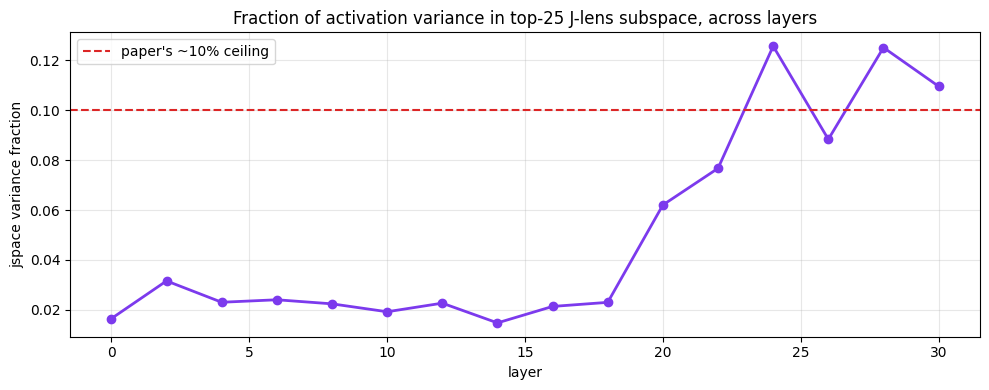

peak jspace fraction: 12.6% at layer 24
mean jspace fraction: 5.0%


In [14]:
# ---- Sweep layers: what fraction of the activation lives in jspace? ----
# 'In jspace' = the projection onto the span of the top-K J-lens vectors at that layer.
K = 25
layers_sweep  = list(lens.source_layers)[::2]   # every other layer for speed
js_fractions  = []

input_ids_local = tokenizer(prompt, return_tensors='pt').input_ids.to(next(hf_model.parameters()).device)

with torch.no_grad():
    with jlens.ActivationRecorder(blocks, at=layers_sweep) as rec:
        _ = hf_model(input_ids=input_ids_local)

for L in layers_sweep:
    # Get the raw activation at (L, -1)
    h_L = rec.activations[L][0, -1].float()             # (d_model,)

    # Compute top-K J-lens vectors via lens.apply
    jl_L, _, _ = lens.apply(model, prompt, layers=[L], positions=[-1])
    top_ids = jl_L[L][0].topk(K).indices

    # Build V and least-squares-project h_L into span(V)
    W_U = hf_model.get_output_embeddings().weight.detach()
    J   = lens.jacobians[L].to(W_U.device, dtype=W_U.dtype)
    V   = (J.T @ W_U[top_ids].T).float()                 # (d_model, K)
    coef, *_ = torch.linalg.lstsq(V, h_L.unsqueeze(-1))  # solve V c = h_L
    coef = coef.squeeze(-1)                               # (K,)
    recon = (V @ coef).float()                            # (d_model,)

    js_var  = (recon ** 2).sum().item()
    tot_var = (h_L   ** 2).sum().item()
    js_fractions.append(js_var / tot_var)

# ---- PLOT: fraction of activation variance in jspace, per layer ----
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(layers_sweep, js_fractions, 'o-', color='#7c3aed', linewidth=2)
ax.axhline(0.10, color='#dc2626', linestyle='--', label="paper's ~10% ceiling")
ax.set_xlabel('layer')
ax.set_ylabel('jspace variance fraction')
ax.set_title(f'Fraction of activation variance in top-{K} J-lens subspace, across layers')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f'peak jspace fraction: {max(js_fractions):.1%} at layer {layers_sweep[int(np.argmax(js_fractions))]}')
print(f'mean jspace fraction: {np.mean(js_fractions):.1%}')

### 6b. Steering: add a concept

$$h_{\ell, t}^{\text{new}} \;=\; h_{\ell, t} \;+\; \alpha \, v_t$$

We sweep $\alpha$ and plot $P(\text{target token})$.

|v_Paris| at L20 = 0.8438


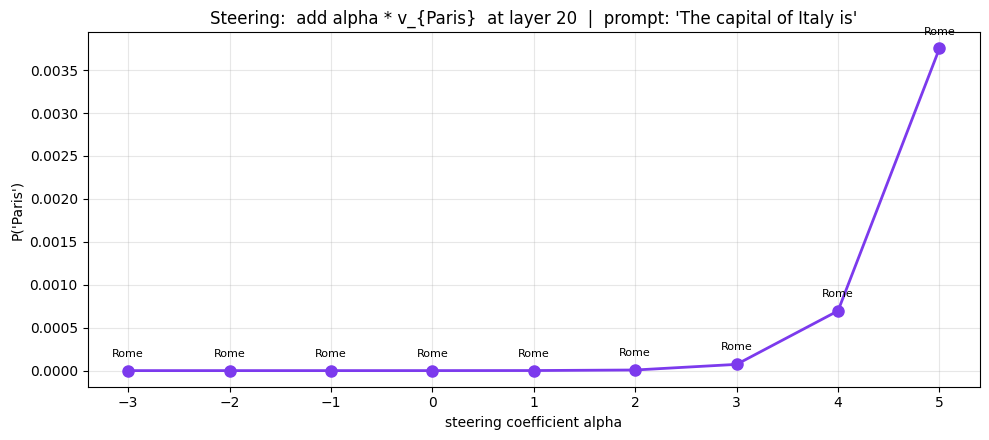

baseline (alpha=0):  P(Paris)=0.0000
max steered:          P(Paris)=0.0038  at alpha=5.0


In [15]:
# ---- Setup ----
STEER_TARGET = 'Paris'                    # single-token concept to inject
STEER_LAYER  = 20                          # workspace range
PROBE_PROMPT = 'The capital of Italy is'   # Paris is 'wrong' here - steering should still bias it

target_ids = tokenizer.encode(STEER_TARGET, add_special_tokens=False)
assert len(target_ids) == 1, f'{STEER_TARGET!r} tokenizes to {target_ids}; want a single token'
TARGET_ID = target_ids[0]

v_target = jlens_vector(lens, STEER_LAYER, TARGET_ID, hf_model)
print(f'|v_{STEER_TARGET}| at L{STEER_LAYER} = {v_target.norm().item():.4f}')

# ---- Sweep alpha, record P(target token) at the next position ----
alphas = np.linspace(-3.0, 5.0, 9)
target_probs = []
top1_tokens = []

for a in alphas:
    with steer(hf_model, layer=STEER_LAYER, vector=v_target, alpha=float(a)):
        logits = next_token_logits(hf_model, tokenizer, PROBE_PROMPT)
    probs = logits.softmax(-1)
    target_probs.append(probs[TARGET_ID].item())
    top1_tokens.append(tokenizer.decode([probs.argmax().item()]).strip())

# ---- PLOT: P(target) vs alpha ----
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(alphas, target_probs, 'o-', color='#7c3aed', linewidth=2, markersize=8)
for a, p, t in zip(alphas, target_probs, top1_tokens):
    ax.annotate(t, (a, p), xytext=(0, 10), textcoords='offset points', fontsize=8, ha='center')
ax.set_xlabel('steering coefficient alpha')
ax.set_ylabel(f'P({STEER_TARGET!r})')
ax.set_title(f'Steering:  add alpha * v_{{{STEER_TARGET}}}  at layer {STEER_LAYER}  |  prompt: {PROBE_PROMPT!r}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'baseline (alpha=0):  P({STEER_TARGET})={target_probs[np.argmin(np.abs(alphas))]:.4f}')
print(f'max steered:          P({STEER_TARGET})={max(target_probs):.4f}  at alpha={alphas[int(np.argmax(target_probs))]}')

### 6c. Ablation: remove a concept

Project $h$ onto the span of the concept vector and subtract:

$$h' \;=\; h \;-\; s \cdot \frac{v^\top h}{\|v\|^2} \, v$$

$s = 0$ leaves $h$ unchanged; $s = 1$ fully ablates.  We sweep $s$ and plot how P(target) collapses.

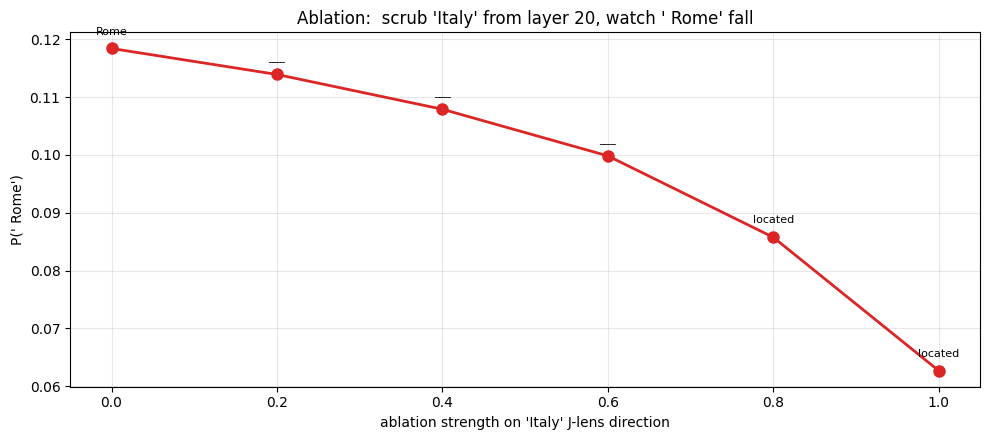

baseline (strength=0):  P( Rome)=0.1184
fully ablated:           P( Rome)=0.0627  (should be much lower)


In [16]:
# ---- Ablate the 'Italy' concept from layer 20, watch P(Rome) drop ----
ABLATE_CONCEPT = 'Italy'
ABLATE_LAYER   = 20
ABLATE_PROBE   = 'The capital of the country shaped like a boot is'
WATCH_TOKEN    = ' Rome'      # what the model SHOULD say - we ablate Italy and watch Rome fall

concept_id = tokenizer.encode(ABLATE_CONCEPT, add_special_tokens=False)[0]
watch_id   = tokenizer.encode(WATCH_TOKEN,    add_special_tokens=False)[0]
v_concept  = jlens_vector(lens, ABLATE_LAYER, concept_id, hf_model)

strengths = np.linspace(0.0, 1.0, 6)
watch_probs = []
top1s = []

for s in strengths:
    with ablate(hf_model, layer=ABLATE_LAYER, vectors=[v_concept], strength=float(s)):
        logits = next_token_logits(hf_model, tokenizer, ABLATE_PROBE)
    probs = logits.softmax(-1)
    watch_probs.append(probs[watch_id].item())
    top1s.append(tokenizer.decode([probs.argmax().item()]).strip())

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(strengths, watch_probs, 'o-', color='#dc2626', linewidth=2, markersize=8)
for s, p, t in zip(strengths, watch_probs, top1s):
    ax.annotate(t, (s, p), xytext=(0, 10), textcoords='offset points', fontsize=8, ha='center')
ax.set_xlabel(f"ablation strength on '{ABLATE_CONCEPT}' J-lens direction")
ax.set_ylabel(f'P({WATCH_TOKEN!r})')
ax.set_title(f'Ablation:  scrub {ABLATE_CONCEPT!r} from layer {ABLATE_LAYER}, watch {WATCH_TOKEN!r} fall')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'baseline (strength=0):  P({WATCH_TOKEN})={watch_probs[0]:.4f}')
print(f'fully ablated:           P({WATCH_TOKEN})={watch_probs[-1]:.4f}  (should be much lower)')

### 6d. Patching: concept swap in lens coordinates

$$V = [v_s \; v_t], \quad c = V^\dagger h, \quad h' \;=\; h + V\,(\sigma(c) - c)$$

This swaps the source/target coefficients while leaving everything orthogonal untouched.

In [17]:
# ---- Swap Italy -> France in the residual stream ----
SOURCE      = 'Italy'
TARGET      = 'France'
PATCH_LAYER = 20
PROMPT_PATCH = 'The capital of the country shaped like a boot is'

src_id = tokenizer.encode(SOURCE, add_special_tokens=False)[0]
tgt_id = tokenizer.encode(TARGET, add_special_tokens=False)[0]
v_src = jlens_vector(lens, PATCH_LAYER, src_id, hf_model)
v_tgt = jlens_vector(lens, PATCH_LAYER, tgt_id, hf_model)

base = generate(hf_model, tokenizer, PROMPT_PATCH, max_new_tokens=8)
with patch_swap(hf_model, layer=PATCH_LAYER, v_src=v_src, v_tgt=v_tgt):
    patched = generate(hf_model, tokenizer, PROMPT_PATCH, max_new_tokens=8)

print(f'PROMPT:   {PROMPT_PATCH!r}')
print(f'  BASE    ({SOURCE}):        {base!r}')
print(f'  PATCHED ({SOURCE}->{TARGET}): {patched!r}')
print()
print('# Should flip from Rome-flavoured answer to Paris-flavoured.  Effect strength varies by layer.')

PROMPT:   'The capital of the country shaped like a boot is'
  BASE    (Italy):        ' Rome.\nA. True\nB'
  PATCHED (Italy->France): ' located at the coordinates (40°'

# Should flip from Rome-flavoured answer to Paris-flavoured.  Effect strength varies by layer.


---

## 7. Replicate paper experiments

Three headline results from the paper.  For a real replication use the paper's eval prompts
in `data/evaluations/` of the repo - the prompts below are illustrative.

### 7a. Two-hop reasoning + concept swap

For a prompt like *'The capital of the country shaped like a boot is'*, the model has to think
'Italy' internally before saying 'Rome'.  We patch Italy -> France at a middle layer and check
whether the model flips to Paris.

**Paper's number:** on 90 two-hop prompts, the flip succeeds on **~61%** of trials.

In [18]:
# ---- 6 two-hop prompts.  Each: (prompt, source_intermediate, target_intermediate,
#                                  base_answer_hint, patched_answer_hint) ----
TWO_HOP_PROMPTS = [
    ('The capital of the country shaped like a boot is',
         'Italy',   'France',   'Rome',    'Paris'),
    ('The currency used in the country whose capital is Berlin is',
         'Germany', 'Japan',    'Euro',    'Yen'),
    ('The main language spoken in the country whose capital is Madrid is',
         'Spain',   'Portugal', 'Spanish', 'Portuguese'),
    ('The currency used in the country whose capital is Ottawa is',
         'Canada',  'Mexico',   'Dollar',  'Peso'),
    ('The main language spoken in the country whose capital is Tokyo is',
         'Japan',   'Korea',    'Japanese','Korean'),
    ('The continent containing the country whose capital is Cairo is',
         'Egypt',   'Brazil',   'Africa',  'South'),
]

L = 20    # workspace-range layer
results = []

for (prompt_txt, s_c, t_c, s_ans, t_ans) in TWO_HOP_PROMPTS:
    s_id = tokenizer.encode(s_c, add_special_tokens=False)[0]
    t_id = tokenizer.encode(t_c, add_special_tokens=False)[0]
    v_s = jlens_vector(lens, L, s_id, hf_model)
    v_t = jlens_vector(lens, L, t_id, hf_model)

    base = generate(hf_model, tokenizer, prompt_txt, max_new_tokens=8)
    with patch_swap(hf_model, layer=L, v_src=v_s, v_tgt=v_t):
        patched = generate(hf_model, tokenizer, prompt_txt, max_new_tokens=8)

    base_hit    = s_ans.lower() in base.lower()
    patched_hit = t_ans.lower() in patched.lower()
    results.append((base_hit, patched_hit))

    print(f'PROMPT:  {prompt_txt}')
    print(f'  BASE    ({s_c}):        {base!r:>40}   ok={base_hit}   [expect {s_ans}]')
    print(f'  PATCHED ({s_c}->{t_c}): {patched!r:>40}   ok={patched_hit} [expect {t_ans}]')
    print()

base_acc    = sum(b for b, _ in results) / len(results)
patched_acc = sum(p for _, p in results) / len(results)
print(f'BASE ANSWER ACCURACY:  {base_acc:.1%}')
print(f'PATCH FLIP ACCURACY:   {patched_acc:.1%}   (paper reports ~61% on 90 prompts)')

PROMPT:  The capital of the country shaped like a boot is
  BASE    (Italy):                            ' Rome.\nA. True\nB'   ok=True   [expect Rome]
  PATCHED (Italy->France):       ' located at the coordinates (40°'   ok=False [expect Paris]

PROMPT:  The currency used in the country whose capital is Berlin is
  BASE    (Germany):                         ' the euro.\nA. True\n'   ok=True   [expect Euro]
  PATCHED (Germany->Japan):                  ' the euro.\nA. True\n'   ok=False [expect Yen]

PROMPT:  The main language spoken in the country whose capital is Madrid is
  BASE    (Spain):                         ' Spanish.\nA. True\nB'   ok=True   [expect Spanish]
  PATCHED (Spain->Portugal):                  ' Spanish.\nA. True\nB'   ok=False [expect Portuguese]

PROMPT:  The currency used in the country whose capital is Ottawa is
  BASE    (Canada):               ' the Canadian dollar.\n\nOttawa'   ok=True   [expect Dollar]
  PATCHED (Canada->Mexico):                   ' the:\nA. 

### 7b. Flexible generalization

The same Italy -> France swap, but three different downstream questions.  If jspace is a real
workspace, all three downstream circuits should read the patched concept consistently.

In [19]:
# ---- One patch, three downstream questions ----
L = 20
src_id = tokenizer.encode('Italy',  add_special_tokens=False)[0]
tgt_id = tokenizer.encode('France', add_special_tokens=False)[0]
v_s = jlens_vector(lens, L, src_id, hf_model)
v_t = jlens_vector(lens, L, tgt_id, hf_model)

QUERIES = [
    ('The capital of the country shaped like a boot is',              'Rome',    'Paris'),
    ('The main language spoken in the country shaped like a boot is', 'Italian', 'French'),
    ('The primary color on the flag of the country shaped like a boot, other than white, is',
                                                                       'green',   'blue'),
]

for (q, base_ans, patched_ans) in QUERIES:
    base    = generate(hf_model, tokenizer, q, max_new_tokens=6)
    with patch_swap(hf_model, layer=L, v_src=v_s, v_tgt=v_t):
        patched = generate(hf_model, tokenizer, q, max_new_tokens=6)
    print(f'BASE   ({base_ans:>8}): {base!r}')
    print(f'PATCHED({patched_ans:>8}): {patched!r}')
    print()

print('If jspace is a workspace, ONE patch flips all three downstream answers consistently.')

BASE   (    Rome): ' Rome.\nA. True'
PATCHED(   Paris): ' located at the coordinates (4'

BASE   ( Italian): '\nA. English\nB'
PATCHED(  French): '\nA. English\nB'

BASE   (   green): ':\nA. Red\n'
PATCHED(    blue): ':\nA. Red\n'

If jspace is a workspace, ONE patch flips all three downstream answers consistently.


### 7c. Ablation ceiling on multi-hop reasoning

Ablate the top-K jspace directions at every layer and watch accuracy on multi-hop prompts fall.

**Expected:** near-ceiling at 0 ablated dims, near-zero at 25 ablated dims.

k_ablate= 0:  accuracy = 83.3%  (5/6)
k_ablate= 5:  accuracy = 83.3%  (5/6)
k_ablate=10:  accuracy = 50.0%  (3/6)
k_ablate=15:  accuracy = 0.0%  (0/6)
k_ablate=20:  accuracy = 0.0%  (0/6)
k_ablate=25:  accuracy = 0.0%  (0/6)


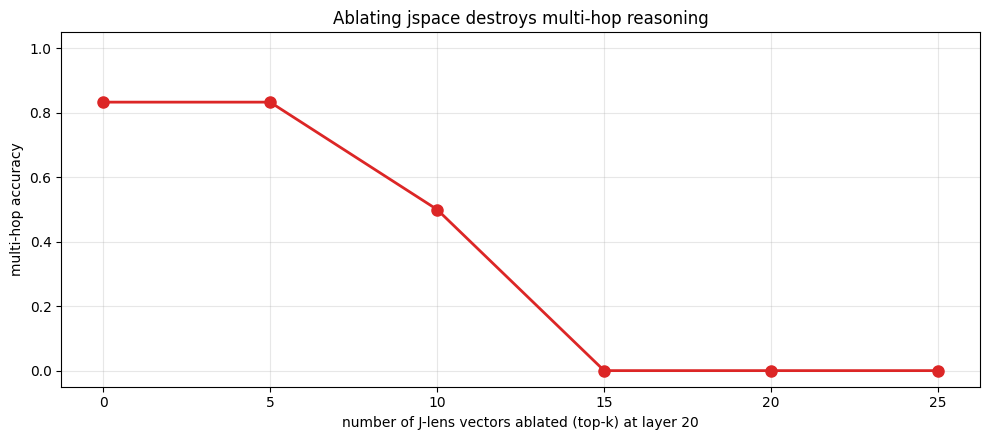

In [20]:
# ---- Multi-hop eval set (small) ----
MULTIHOP_PROMPTS = [
    ('The capital of the country shaped like a boot is',           'Rome'),
    ('The main language spoken in the country whose capital is Tokyo is', 'Japanese'),
    ('The continent containing the country whose capital is Cairo is',  'Africa'),
    ('The currency used in the country whose flag has a maple leaf is', 'Dollar'),
    ('The main language spoken in the country whose capital is Paris is', 'French'),
    ('The currency used in the country shaped like a boot is',           'Euro'),
]

def check(prompt_text, expected, k_ablate=0):
    '''Ablate the top-k_ablate J-lens vectors at ONE middle layer, then check the answer.'''
    if k_ablate == 0:
        out = generate(hf_model, tokenizer, prompt_text, max_new_tokens=6)
    else:
        # top-K lens tokens at layer L, pos=-1  ->  their J-lens vectors  ->  ablate all
        L = 20
        jl, _, _ = lens.apply(model, prompt_text, layers=[L], positions=[-1])
        top_ids = jl[L][0].topk(k_ablate).indices.tolist()
        vs = [jlens_vector(lens, L, i, hf_model) for i in top_ids]
        with ablate(hf_model, layer=L, vectors=vs, strength=1.0):
            out = generate(hf_model, tokenizer, prompt_text, max_new_tokens=6)
    return int(expected.lower() in out.lower())

# Sweep k from 0 to 25
ks = [0, 5, 10, 15, 20, 25]
accs = []
for k in ks:
    correct = sum(check(p, e, k_ablate=k) for p, e in MULTIHOP_PROMPTS)
    accs.append(correct / len(MULTIHOP_PROMPTS))
    print(f'k_ablate={k:>2}:  accuracy = {accs[-1]:.1%}  ({correct}/{len(MULTIHOP_PROMPTS)})')

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(ks, accs, 'o-', color='#dc2626', linewidth=2, markersize=8)
ax.set_xlabel('number of J-lens vectors ablated (top-k) at layer 20')
ax.set_ylabel('multi-hop accuracy')
ax.set_title("Ablating jspace destroys multi-hop reasoning")
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## 8. Fit your own lens on another model

For any model besides Qwen 3.5 4B / 3.6 27B, fit your own lens with `jlens.fit`.
It runs backward passes over a corpus of prompts and averages the Jacobians into `J_\ell` per layer.

- **100 prompts** is enough for a usable lens; released lenses use 1000.
- `dim_batch` is the memory knob (smaller = less memory, more passes).
- Expect ~5-30 minutes on a single GPU for a small model.

Below we fit on a *different* HuggingFace model, then rerun the readout + patch on it.

In [21]:
# ---- Pick a smaller model - one you can afford to fit a lens on ----
NEW_MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'

new_hf    = transformers.AutoModelForCausalLM.from_pretrained(NEW_MODEL_NAME, dtype=DTYPE).to(DEVICE)
new_tok   = transformers.AutoTokenizer.from_pretrained(NEW_MODEL_NAME)
new_model = jlens.from_hf(new_hf, new_tok)
print(f'{NEW_MODEL_NAME}   n_layers={new_model.n_layers}   d_model={new_model.d_model}')

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Qwen/Qwen2.5-1.5B-Instruct   n_layers=28   d_model=1536


In [22]:
# ---- Load a generic prompt corpus for fitting ----
# You can use ANY iterable of strings.  We use wikitext for consistency with released lenses.
from datasets import load_dataset

ds = load_dataset('Salesforce/wikitext', 'wikitext-103-raw-v1', split='train', streaming=True)
prompts_fit = []
for row in ds:
    text = row['text'].strip()
    if len(text) > 50:                                    # skip very short lines
        prompts_fit.append(text[:512])                    # cap length
    if len(prompts_fit) >= 100:                           # 100 prompts is enough
        break
print(f'{len(prompts_fit)} prompts loaded for fitting')
print(f'sample: {prompts_fit[0][:100]}...')

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

100 prompts loaded for fitting
sample: Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlef...


In [23]:
# ---- Fit the lens.  ~5-15 min on GPU for 1.5B model, ~30-60 min on MPS/CPU. ----
# `jlens.fit` returns a JacobianLens with one J matrix per source layer.
new_lens = jlens.fit(
    new_model,
    prompts=prompts_fit,
    dim_batch=32,                # backward-pass batch in the d_model dim
    max_seq_len=128,
    checkpoint_path='my_new_lens.pt',
)
new_lens.save('my_new_lens.pt')
print(f'fitted  ({len(new_lens.source_layers)} layers)')

[  6m02s +362.84s] fit: n_layers=28 d_model=1536, fitting 27 source layers (target=L27) on 100 prompts
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
[  6m21s + 18.38s]   prompt 1/100  seq_len=127 n_valid=110  18s  max||J||/sqrt(d)=1.529  max_d_mean=nan
[  6m36s + 15.62s]   prompt 2/100  seq_len=105 n_valid=88  15s  max||J||/sqrt(d)=1.631  max_d_mean=5.27e-01
[  6m52s + 15.51s]   prompt 3/100  seq_len=102 n_valid=85  15s  max||J||/sqrt(d)=1.369  max_d_mean=2.85e-01
[  7m06s + 13.83s]   prompt 4/100  seq_len=92 n_valid=75  13s  max||J||/sqrt(d)=1.855  max_d_mean=3.70e-01
[  7m22s + 16.10s]   prompt 5/100  seq_len=105 n_valid=88  16s  max||J||/sqrt(d)=1.664  max_d_mean

fitted  (27 layers)


### 8.1  Readout on the newly-fitted lens

Same routine as §4.  If the new lens is well-fit, the J-lens should surface interpretable content
at middle layers, similar to what we saw with the pre-fit Qwen 3.5 4B lens.

In [24]:
sl_new = new_lens.source_layers
layers_to_probe = [sl_new[len(sl_new) // 4], sl_new[len(sl_new) // 2],
                   sl_new[len(sl_new) // 4 * 3], sl_new[-1]]

jl_new, _, _ = new_lens.apply(new_model, prompt, layers=layers_to_probe, positions=[-2])
ll_new, _, _ = new_lens.apply(new_model, prompt, layers=layers_to_probe, positions=[-2], use_jacobian=False)

for L in layers_to_probe:
    jl5 = [new_tok.decode([t]) for t in jl_new[L][0].topk(5).indices]
    ll5 = [new_tok.decode([t]) for t in ll_new[L][0].topk(5).indices]
    print(f'L{L:>3}   logit-lens: {ll5}')
    print(f'L{L:>3}   J-lens:     {jl5}')
    print()

L  6   logit-lens: ['camp', ' Real', 'ing', ' Kö', 'leg']
L  6   J-lens:     ['”', '”.', 'ﬁ', 'ﬂ', '”,']

L 13   logit-lens: [' Bil', 'fish', '北部', ' Di', 'Di']
L 13   J-lens:     ['”.', '”,', '”.\n\n', '”)', 'ﬁ']

L 18   logit-lens: ['北部', '之称', ' nation', '/blue', '在我国']
L 18   J-lens:     ['”,', '”.', '”:', '”;', '”，']

L 26   logit-lens: [' is', ' was', ' has', ' consists', ' includes']
L 26   J-lens:     [' is', ' includes', ' consists', ' has', ' was']



In [25]:
# ---- Italy -> France concept swap on the new model too ----
src_id = new_tok.encode('Italy',  add_special_tokens=False)[0]
tgt_id = new_tok.encode('France', add_special_tokens=False)[0]

def jlens_vector_new(L, tok_id):
    J   = new_lens.jacobians[L]
    W_U = new_hf.get_output_embeddings().weight
    u_v = W_U[tok_id].detach()
    return J.to(u_v.device, dtype=u_v.dtype).T @ u_v

def transformer_blocks_new():
    return new_hf.model.layers

@contextmanager
def patch_swap_new(L, v_s, v_t):
    block = transformer_blocks_new()[L]
    V = torch.stack([v_s, v_t]).T.float()
    def hook(mod, inp, out):
        h, wrap = _unwrap(out)
        Vd = V.to(h.device, dtype=h.dtype)
        pinv = torch.linalg.pinv(Vd.float()).to(h.dtype)
        c = h @ pinv.T
        swapped = torch.stack([c[..., 1], c[..., 0]], dim=-1)
        h = h + (swapped - c) @ Vd.T
        return wrap(h)
    handle = block.register_forward_hook(hook)
    try:    yield
    finally: handle.remove()

L_new = sl_new[len(sl_new) // 2]
v_s = jlens_vector_new(L_new, src_id)
v_t = jlens_vector_new(L_new, tgt_id)

test_prompt = 'The capital of the country shaped like a boot is'
base    = generate(new_hf, new_tok, test_prompt, max_new_tokens=8)
with patch_swap_new(L_new, v_s, v_t):
    patched = generate(new_hf, new_tok, test_prompt, max_new_tokens=8)

print(f'BASE    (Italy):         {base!r}')
print(f'PATCHED (Italy->France): {patched!r}')

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


BASE    (Italy):         ' ____\nA. Rome\nB.'
PATCHED (Italy->France): ' ____\nA. Athens\nB.'


---

## Wrap-up

The full loop:

1. **Compute** the Jacobian per layer, average over prompts -> $J_\ell$.
2. **Read** activations by top-K of $W_U J_\ell h$ -> J-lens tokens.
3. **Decompose** an activation into a sparse combination of J-lens vectors.
4. **Intervene** by adding, ablating, or swapping J-lens directions in the residual stream.
5. **Verify** multi-hop reasoning routes through jspace by ablating it and watching accuracy fall.

Things to try:

- Vary `TARGET_LAYER` and `STEER_LAYER` in §6 - workspace range is ~38-92% depth.
- Change prompts in §7b - flexibility across downstream questions is the strongest workspace signal.
- Run §8 with a Llama variant to see whether the properties transport across model families.